# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 34: AUDIO MULTI-LABEL EXPANDED PILOT
# ============================================================
# Purpose:
# This notebook retrains the audio multi-label candidate-150 CNN
# on a larger pilot subset than Notebook 30.
#
# The goal is to:
# 1. Rebuild a larger deterministic pilot subset
# 2. Train the same audio multi-label CNN on more data
# 3. Tune the global decision threshold on validation data
# 4. Evaluate on the expanded test split
# 5. Save outputs for later expanded hybrid fusion
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import gc
import math
import random
import warnings

import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    f1_score,
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seeds set to:", SEED)
print("TensorFlow version:", tf.__version__)

Seeds set to: 42
TensorFlow version: 2.20.0


In [2]:
# ============================================================
# 2. LOAD MULTI-LABEL MASTER TABLE
# ============================================================

master_df = pd.read_csv("../data/processed/multilabel_candidate_master_table.csv")

print("Candidate multi-label master shape:", master_df.shape)
display(master_df.head())

Candidate multi-label master shape: (81574, 157)


,track_id,split,subset,genre_top,title,audio_path,audio_exists,genre_1,genre_2,genre_3,...,genre_693,genre_695,genre_741,genre_763,genre_810,genre_811,genre_906,genre_1156,genre_1193,genre_1235
0,20,training,large,NaN,Spiritual Level,../data/raw/audio/fma_large\000\000020.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,26,training,large,NaN,Where is your Love?,../data/raw/audio/fma_large\000\000026.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,30,training,large,NaN,Too Happy,../data/raw/audio/fma_large\000\000030.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,46,training,large,NaN,Yosemite,../data/raw/audio/fma_large\000\000046.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,48,training,large,NaN,Light of Light,../data/raw/audio/fma_large\000\000048.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# ============================================================
# 3. IDENTIFY LABEL COLUMNS
# ============================================================

label_cols = [
    col for col in master_df.columns
    if col.startswith("genre_") and col.replace("genre_", "").isdigit()
]

print("Number of candidate label columns:", len(label_cols))
print("First 10 label columns:", label_cols[:10])

print("\nNon-label genre-like columns:")
print([col for col in master_df.columns if col.startswith("genre_") and col not in label_cols])

Number of candidate label columns: 150
First 10 label columns: ['genre_1', 'genre_2', 'genre_3', 'genre_4', 'genre_5', 'genre_6', 'genre_7', 'genre_8', 'genre_9', 'genre_10']

Non-label genre-like columns:
['genre_top']


In [4]:
# ============================================================
# 4. FILTER TO USABLE AUDIO MULTI-LABEL ROWS
# ============================================================

master_df["candidate_label_count"] = master_df[label_cols].sum(axis=1)

usable_df = master_df[
    (master_df["candidate_label_count"] > 0) &
    (master_df["audio_exists"] == True)
].copy().reset_index(drop=True)

print("Original candidate master shape:", master_df.shape)
print("Usable audio multi-label shape:", usable_df.shape)

print("\nSplit distribution:")
print(usable_df["split"].value_counts())

print("\nCandidate label count summary:")
print(usable_df["candidate_label_count"].describe())

Original candidate master shape: (81574, 158)
Usable audio multi-label shape: (79343, 158)

Split distribution:
split
training      62452
test           8548
validation     8343
Name: count, dtype: int64

Candidate label count summary:
count    79343.000000
mean         3.679329
std          1.735141
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         31.000000
Name: candidate_label_count, dtype: float64


In [5]:
# ============================================================
# 5. BUILD A LARGER DETERMINISTIC PILOT
# ============================================================
# This is intentionally larger than Notebook 30.
# If your machine struggles, reduce these values.

TRAIN_CAP = 8000
VAL_CAP = 1500
TEST_CAP = 1500

def sample_split(df, split_name, n, seed=42):
    sub = df[df["split"] == split_name].copy()
    if len(sub) > n:
        sub = sub.sample(n=n, random_state=seed)
    sub = sub.sort_values("track_id").reset_index(drop=True)
    return sub

train_df = sample_split(usable_df, "training", TRAIN_CAP, seed=SEED)
val_df = sample_split(usable_df, "validation", VAL_CAP, seed=SEED)
test_df = sample_split(usable_df, "test", TEST_CAP, seed=SEED)

print("Expanded pilot split sizes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nAverage labels per track in expanded pilot:")
print("Train:", train_df[label_cols].sum(axis=1).mean())
print("Validation:", val_df[label_cols].sum(axis=1).mean())
print("Test:", test_df[label_cols].sum(axis=1).mean())

Expanded pilot split sizes:
Train: (8000, 158)
Validation: (1500, 158)
Test: (1500, 158)

Average labels per track in expanded pilot:
Train: 3.636
Validation: 3.9086666666666665
Test: 3.715333333333333


In [6]:
# ============================================================
# 6. CHECK LABEL COVERAGE
# ============================================================

train_label_counts = train_df[label_cols].sum(axis=0)
val_label_counts = val_df[label_cols].sum(axis=0)
test_label_counts = test_df[label_cols].sum(axis=0)

print("Labels present in train:", int((train_label_counts > 0).sum()), "out of", len(label_cols))
print("Labels present in validation:", int((val_label_counts > 0).sum()), "out of", len(label_cols))
print("Labels present in test:", int((test_label_counts > 0).sum()), "out of", len(label_cols))

print("\nTrain label count summary:")
print(train_label_counts.describe())

Labels present in train: 147 out of 150
Labels present in validation: 145 out of 150
Labels present in test: 141 out of 150

Train label count summary:
count     150.00000
mean      193.92000
std       467.44326
min         0.00000
25%        12.00000
50%        46.00000
75%       154.00000
max      3570.00000
dtype: float64


In [7]:
# ============================================================
# 7. SAVE EXPANDED PILOT SPLITS
# ============================================================

os.makedirs("../data/processed", exist_ok=True)

train_df.to_csv("../data/processed/audio_multilabel_candidate150_expanded_train.csv", index=False)
val_df.to_csv("../data/processed/audio_multilabel_candidate150_expanded_val.csv", index=False)
test_df.to_csv("../data/processed/audio_multilabel_candidate150_expanded_test.csv", index=False)

print("Saved expanded pilot metadata.")

Saved expanded pilot metadata.


In [8]:
# ============================================================
# 8. AUDIO PREPROCESSING SETTINGS
# ============================================================

# Keep preprocessing the same as Notebook 30 so changes are mainly
# due to more data rather than a different front-end.

SR = 22050
DURATION = 15
N_MELS = 64
N_FFT = 2048
HOP_LENGTH = 1024

MAX_FRAMES = int(np.ceil((DURATION * SR) / HOP_LENGTH)) + 1

BATCH_SIZE = 6
NUM_LABELS = len(label_cols)

print("SR:", SR)
print("DURATION:", DURATION)
print("N_MELS:", N_MELS)
print("MAX_FRAMES:", MAX_FRAMES)
print("BATCH_SIZE:", BATCH_SIZE)
print("NUM_LABELS:", NUM_LABELS)

SR: 22050
DURATION: 15
N_MELS: 64
MAX_FRAMES: 324
BATCH_SIZE: 6
NUM_LABELS: 150


In [9]:
# ============================================================
# 9. AUDIO LOADING HELPER
# ============================================================

bad_audio_paths = set()

def safe_load_melspectrogram(file_path, sr=SR, duration=DURATION,
                             n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH,
                             max_frames=MAX_FRAMES):
    try:
        y, _ = librosa.load(file_path, sr=sr, mono=True, duration=duration)

        if y is None or len(y) == 0:
            bad_audio_paths.add(file_path)
            return np.zeros((n_mels, max_frames), dtype=np.float32)

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = np.clip((mel_db + 80.0) / 80.0, 0.0, 1.0)

        if mel_db.shape[1] < max_frames:
            pad_width = max_frames - mel_db.shape[1]
            mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode="constant")
        else:
            mel_db = mel_db[:, :max_frames]

        return mel_db.astype(np.float32)

    except Exception:
        bad_audio_paths.add(file_path)
        return np.zeros((n_mels, max_frames), dtype=np.float32)

In [10]:
# ============================================================
# 10. KERAS SEQUENCE GENERATOR
# ============================================================

class AudioMultiLabelSequence(tf.keras.utils.Sequence):
    def __init__(self, df, label_cols, batch_size=BATCH_SIZE, shuffle=False, **kwargs):
        super().__init__(**kwargs)
        self.df = df.reset_index(drop=True).copy()
        self.label_cols = label_cols
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_idx]

        X_batch = np.zeros((len(batch_df), N_MELS, MAX_FRAMES, 1), dtype=np.float32)
        y_batch = np.zeros((len(batch_df), len(self.label_cols)), dtype=np.float32)

        for i, (_, row) in enumerate(batch_df.iterrows()):
            mel = safe_load_melspectrogram(row["audio_path"])
            X_batch[i, :, :, 0] = mel
            y_batch[i] = row[self.label_cols].values.astype(np.float32)

        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [11]:
# ============================================================
# 11. CREATE GENERATORS
# ============================================================

train_gen = AudioMultiLabelSequence(train_df, label_cols, batch_size=BATCH_SIZE, shuffle=True)
val_gen = AudioMultiLabelSequence(val_df, label_cols, batch_size=BATCH_SIZE, shuffle=False)
test_gen = AudioMultiLabelSequence(test_df, label_cols, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_gen))
print("Validation batches:", len(val_gen))
print("Test batches:", len(test_gen))

sample_X, sample_y = train_gen[0]
print("Sample batch X shape:", sample_X.shape)
print("Sample batch y shape:", sample_y.shape)

Train batches: 1334
Validation batches: 250
Test batches: 250
Sample batch X shape: (6, 64, 324, 1)
Sample batch y shape: (6, 150)


In [12]:
# ============================================================
# 12. BUILD THE AUDIO MULTI-LABEL CNN
# ============================================================
# Slightly stronger than Notebook 30, but still laptop-safe.

tf.keras.backend.clear_session()
gc.collect()

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(N_MELS, MAX_FRAMES, 1)),

    tf.keras.layers.Conv2D(24, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(48, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(96, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(96, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(160, activation="relu"),
    tf.keras.layers.Dropout(0.35),
    tf.keras.layers.Dense(NUM_LABELS, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=8e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="bin_acc"),
        tf.keras.metrics.AUC(name="auc", multi_label=True, num_labels=NUM_LABELS)
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 324, 24)    │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 324, 24)    │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 162, 24)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 162, 48)    │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 162, 48)    │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 81, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 81, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 81, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 40, 96)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 40, 96)      │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 40, 96)      │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 160)            │        15,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 150)            │        24,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,990 (687.46 KB)

 Trainable params: 175,462 (685.40 KB)

 Non-trainable params: 528 (2.06 KB)

In [13]:
# ============================================================
# 13. TRAIN THE EXPANDED AUDIO MODEL
# ============================================================

os.makedirs("../models", exist_ok=True)

checkpoint_path = "../models/audio_multilabel_candidate150_expanded_best.keras"

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

if os.path.exists(checkpoint_path):
    model = tf.keras.models.load_model(checkpoint_path)

print("Expanded audio training complete.")

Epoch 1/10
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - auc: 0.4742 - bin_acc: 0.9529 - loss: 0.1500
Epoch 1: val_auc improved from -inf to 0.51103, saving model to ../models/audio_multilabel_candidate150_expanded_best.keras
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 766s 572ms/step - auc: 0.4742 - bin_acc: 0.9530 - loss: 0.1499 - val_auc: 0.5110 - val_bin_acc: 0.9749 - val_loss: 0.0986 - learning_rate: 8.0000e-04
Epoch 2/10
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - auc: 0.5419 - bin_acc: 0.9767 - loss: 0.0800
Epoch 2: val_auc improved from 0.51103 to 0.52006, saving model to ../models/audio_multilabel_candidate150_expanded_best.keras
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 606s 454ms/step - auc: 0.5420 - bin_acc: 0.9767 - loss: 0.0800 - val_auc: 0.5201 - val_bin_acc: 0.9733 - val_loss: 0.1040 - learning_rate: 8.0000e-04
Epoch 3/10
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - auc: 0.5663 - bin_acc: 0.9771 - loss: 0.0775
Epoch 3: val_auc improved from 0.52006 to 0.57464, saving model to ../models/a

,auc,bin_acc,loss,val_auc,val_bin_acc,val_loss,learning_rate
0,0.527198,0.971473,0.099688,0.511026,0.974867,0.098568,0.0008
1,0.576709,0.976738,0.079325,0.520055,0.973267,0.103954,0.0008
2,0.607887,0.977215,0.076824,0.574644,0.973783,0.094195,0.0008
3,0.636496,0.977573,0.075071,0.594084,0.975729,0.087860,0.0008
4,0.646703,0.977703,0.074349,0.556871,0.973964,0.094190,0.0008


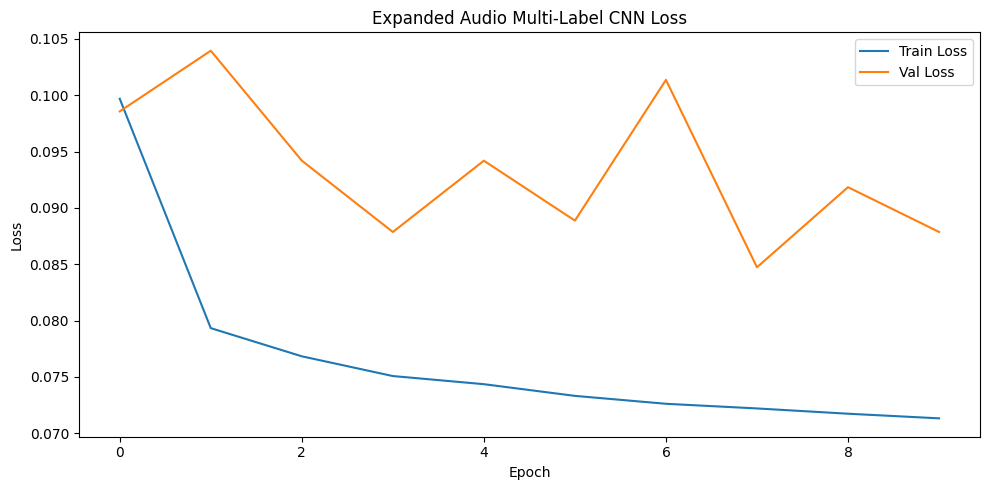

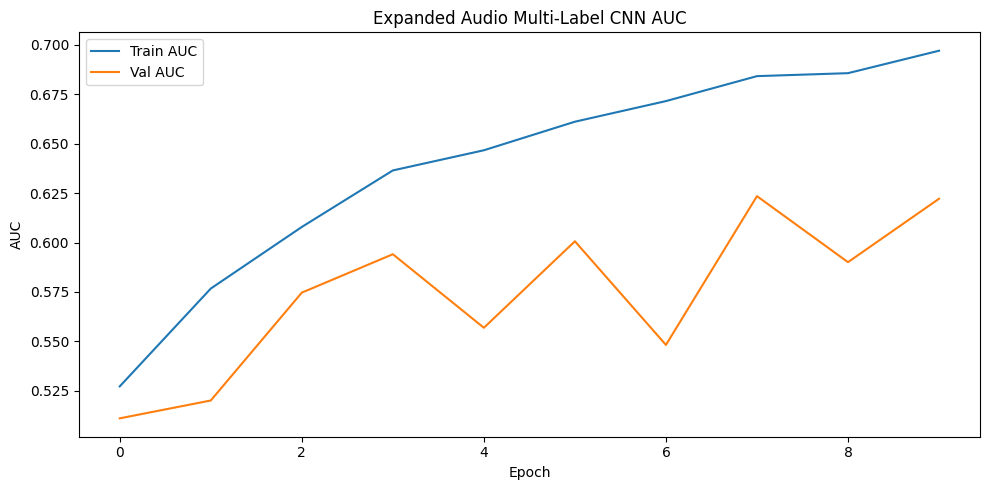

In [14]:
# ============================================================
# 14. PLOT TRAINING CURVES
# ============================================================

history_df = pd.DataFrame(history.history)
display(history_df.head())

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Expanded Audio Multi-Label CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Val AUC")
plt.title("Expanded Audio Multi-Label CNN AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 15. PREDICT VALIDATION AND TEST PROBABILITIES
# ============================================================

val_probs = model.predict(val_gen, verbose=1)
test_probs = model.predict(test_gen, verbose=1)

Y_val = val_df[label_cols].values.astype(np.uint8)
Y_test = test_df[label_cols].values.astype(np.uint8)

print("Validation probabilities shape:", val_probs.shape)
print("Test probabilities shape:", test_probs.shape)
print("Y_val shape:", Y_val.shape)
print("Y_test shape:", Y_test.shape)

250/250 ━━━━━━━━━━━━━━━━━━━━ 46s 182ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 96s 386ms/step
Validation probabilities shape: (1500, 150)
Test probabilities shape: (1500, 150)
Y_val shape: (1500, 150)
Y_test shape: (1500, 150)


In [16]:
# ============================================================
# 16. EVALUATION HELPERS
# ============================================================

def evaluate_multilabel(y_true, y_pred, name="Model"):
    return {
        "Model": name,
        "Micro F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Samples F1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "Micro Precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "Micro Recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "Hamming Loss": hamming_loss(y_true, y_pred),
        "Subset Accuracy": accuracy_score(y_true, y_pred),
        "Avg Predicted Labels": float(y_pred.sum(axis=1).mean())
    }

def precision_recall_at_k(y_true, score_matrix, k=3):
    y_true = np.asarray(y_true)
    topk_idx = np.argsort(-score_matrix, axis=1)[:, :k]

    precision_vals = []
    recall_vals = []

    for i in range(y_true.shape[0]):
        true_idx = np.where(y_true[i] == 1)[0]
        if len(true_idx) == 0:
            continue

        pred_idx = topk_idx[i]
        hits = len(set(pred_idx).intersection(set(true_idx)))

        precision_vals.append(hits / k)
        recall_vals.append(hits / len(true_idx))

    return float(np.mean(precision_vals)), float(np.mean(recall_vals))

def decode_threshold(prob_matrix, threshold, ensure_at_least_one=False):
    y_pred = (prob_matrix >= threshold).astype(np.uint8)

    if ensure_at_least_one:
        row_sums = y_pred.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]

        if len(zero_rows) > 0:
            top_idx = np.argmax(prob_matrix[zero_rows], axis=1)
            y_pred[zero_rows, top_idx] = 1

    return y_pred

In [17]:
# ============================================================
# 17. DEFAULT THRESHOLD EVALUATION
# ============================================================

default_threshold = 0.5

Y_val_pred_default = decode_threshold(val_probs, default_threshold, ensure_at_least_one=False)
Y_test_pred_default = decode_threshold(test_probs, default_threshold, ensure_at_least_one=False)

default_val_results = evaluate_multilabel(
    Y_val, Y_val_pred_default, name="Expanded Audio CNN - Default Threshold"
)

default_test_results = evaluate_multilabel(
    Y_test, Y_test_pred_default, name="Expanded Audio CNN - Default Threshold"
)

p3_val, r3_val = precision_recall_at_k(Y_val, val_probs, k=3)
p5_val, r5_val = precision_recall_at_k(Y_val, val_probs, k=5)

default_val_results["Precision@3"] = p3_val
default_val_results["Recall@3"] = r3_val
default_val_results["Precision@5"] = p5_val
default_val_results["Recall@5"] = r5_val

p3_test, r3_test = precision_recall_at_k(Y_test, test_probs, k=3)
p5_test, r5_test = precision_recall_at_k(Y_test, test_probs, k=5)

default_test_results["Precision@3"] = p3_test
default_test_results["Recall@3"] = r3_test
default_test_results["Precision@5"] = p5_test
default_test_results["Recall@5"] = r5_test

print("Default validation results:")
print(default_val_results)

print("\nDefault test results:")
print(default_test_results)

Default validation results:
{'Model': 'Expanded Audio CNN - Default Threshold', 'Micro F1': 0.22206506364922207, 'Macro F1': 0.010458783050125674, 'Samples F1': 0.22139322529322528, 'Micro Precision': 0.6503728251864126, 'Micro Recall': 0.1338904997441583, 'Hamming Loss': 0.024444444444444446, 'Subset Accuracy': 0.02266666666666667, 'Avg Predicted Labels': 0.8046666666666666, 'Precision@3': 0.442, 'Recall@3': 0.3776197354497355, 'Precision@5': 0.33720000000000006, 'Recall@5': 0.4760583068783069}

Default test results:
{'Model': 'Expanded Audio CNN - Default Threshold', 'Micro F1': 0.22241861835321844, 'Macro F1': 0.012375314575467169, 'Samples F1': 0.21553252673252674, 'Micro Precision': 0.6208881578947368, 'Micro Recall': 0.13547460972546205, 'Hamming Loss': 0.02346222222222222, 'Subset Accuracy': 0.01, 'Avg Predicted Labels': 0.8106666666666666, 'Precision@3': 0.4231111111111111, 'Recall@3': 0.3743705146705147, 'Precision@5': 0.3285333333333333, 'Recall@5': 0.4762671236171236}


In [18]:
# ============================================================
# 18. GLOBAL THRESHOLD SEARCH
# ============================================================

threshold_grid = np.arange(0.05, 0.65, 0.05)

threshold_results = []

for t in threshold_grid:
    Y_val_pred_t = decode_threshold(val_probs, t, ensure_at_least_one=False)

    results = evaluate_multilabel(
        Y_val,
        Y_val_pred_t,
        name=f"Expanded Audio CNN @ {t:.2f}"
    )

    results["Threshold"] = float(t)
    threshold_results.append(results)

threshold_results_df = pd.DataFrame(threshold_results).sort_values(
    ["Micro F1", "Macro F1", "Samples F1"],
    ascending=False
).reset_index(drop=True)

print("Expanded validation threshold search:")
display(threshold_results_df)

Expanded validation threshold search:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Threshold
0,Expanded Audio CNN @ 0.20,0.390449,0.034615,0.388606,0.432842,0.355620,0.028933,0.002667,3.211333,0.20
1,Expanded Audio CNN @ 0.15,0.384591,0.040657,0.382235,0.355478,0.418898,0.034933,0.000667,4.606000,0.15
2,Expanded Audio CNN @ 0.25,0.374252,0.027365,0.371957,0.486885,0.303940,0.026484,0.007333,2.440000,0.25
3,Expanded Audio CNN @ 0.10,0.356677,0.050775,0.353423,0.271930,0.518165,0.048707,0.000667,7.448000,0.10
4,Expanded Audio CNN @ 0.30,0.351974,0.021229,0.350970,0.531908,0.263005,0.025236,0.014667,1.932667,0.30
5,Expanded Audio CNN @ 0.35,0.323045,0.018449,0.323010,0.567266,0.225823,0.024662,0.019333,1.556000,0.35
6,Expanded Audio CNN @ 0.40,0.289073,0.015020,0.291454,0.595530,0.190858,0.024462,0.022667,1.252667,0.40
7,Expanded Audio CNN @ 0.05,0.282580,0.062520,0.279903,0.179369,0.665530,0.088058,0.000000,14.502667,0.05
8,Expanded Audio CNN @ 0.45,0.255688,0.012264,0.255865,0.620644,0.161010,0.024427,0.024000,1.014000,0.45
9,Expanded Audio CNN @ 0.50,0.222065,0.010459,0.221393,0.650373,0.133890,0.024444,0.022667,0.804667,0.50


In [19]:
# ============================================================
# 19. SELECT BEST THRESHOLD
# ============================================================

best_threshold = float(threshold_results_df.iloc[0]["Threshold"])
best_val_micro_f1 = float(threshold_results_df.iloc[0]["Micro F1"])

print("Best threshold:", best_threshold)
print("Best validation Micro F1:", best_val_micro_f1)

Best threshold: 0.2
Best validation Micro F1: 0.3904494382022472


In [20]:
# ============================================================
# 20. APPLY BEST THRESHOLD TO TEST
# ============================================================

Y_val_pred_tuned = decode_threshold(val_probs, best_threshold, ensure_at_least_one=False)
Y_test_pred_tuned = decode_threshold(test_probs, best_threshold, ensure_at_least_one=False)

tuned_val_results = evaluate_multilabel(
    Y_val, Y_val_pred_tuned, name="Expanded Audio CNN - Tuned Threshold"
)

tuned_test_results = evaluate_multilabel(
    Y_test, Y_test_pred_tuned, name="Expanded Audio CNN - Tuned Threshold"
)

tuned_val_results["Precision@3"] = p3_val
tuned_val_results["Recall@3"] = r3_val
tuned_val_results["Precision@5"] = p5_val
tuned_val_results["Recall@5"] = r5_val

tuned_test_results["Precision@3"] = p3_test
tuned_test_results["Recall@3"] = r3_test
tuned_test_results["Precision@5"] = p5_test
tuned_test_results["Recall@5"] = r5_test

print("Tuned validation results:")
print(tuned_val_results)

print("\nTuned test results:")
print(tuned_test_results)

Tuned validation results:
{'Model': 'Expanded Audio CNN - Tuned Threshold', 'Micro F1': 0.3904494382022472, 'Macro F1': 0.03461534815738046, 'Samples F1': 0.38860570910570913, 'Micro Precision': 0.43284201785343573, 'Micro Recall': 0.35561998976633125, 'Hamming Loss': 0.028933333333333332, 'Subset Accuracy': 0.0026666666666666666, 'Avg Predicted Labels': 3.211333333333333, 'Precision@3': 0.442, 'Recall@3': 0.3776197354497355, 'Precision@5': 0.33720000000000006, 'Recall@5': 0.4760583068783069}

Tuned test results:
{'Model': 'Expanded Audio CNN - Tuned Threshold', 'Micro F1': 0.3817040699885888, 'Macro F1': 0.0405395808949723, 'Samples F1': 0.37911724571724564, 'Micro Precision': 0.40602872749342506, 'Micro Recall': 0.3601291943298044, 'Hamming Loss': 0.02889777777777778, 'Subset Accuracy': 0.0013333333333333333, 'Avg Predicted Labels': 3.2953333333333332, 'Precision@3': 0.4231111111111111, 'Recall@3': 0.3743705146705147, 'Precision@5': 0.3285333333333333, 'Recall@5': 0.4762671236171236}

In [21]:
# ============================================================
# 21. COMPARE DEFAULT VS TUNED TEST RESULTS
# ============================================================

test_comparison_df = pd.DataFrame([
    default_test_results,
    tuned_test_results
])

print("Expanded audio default vs tuned test comparison:")
display(test_comparison_df)

Expanded audio default vs tuned test comparison:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Expanded Audio CNN - Default Threshold,0.222419,0.012375,0.215533,0.620888,0.135475,0.023462,0.010000,0.810667,0.423111,0.374371,0.328533,0.476267
1,Expanded Audio CNN - Tuned Threshold,0.381704,0.040540,0.379117,0.406029,0.360129,0.028898,0.001333,3.295333,0.423111,0.374371,0.328533,0.476267


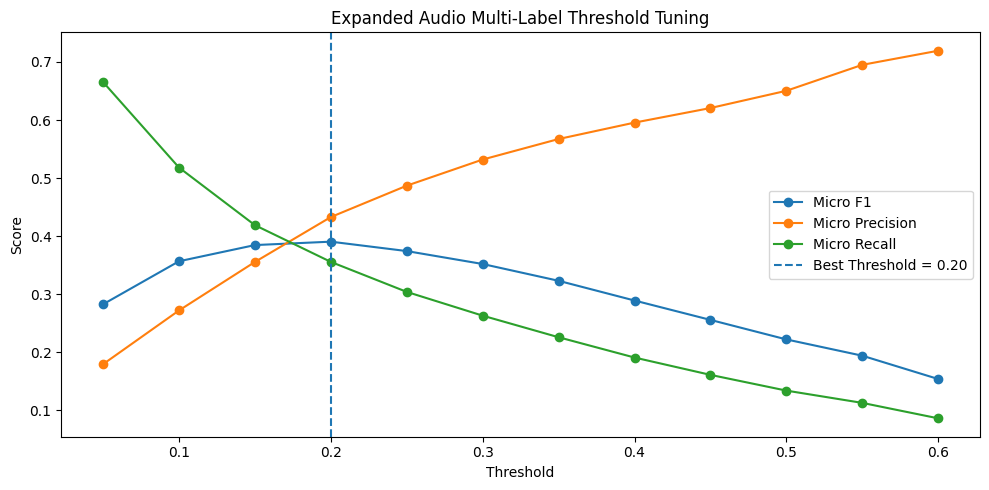

In [22]:
# ============================================================
# 22. PLOT THRESHOLD TUNING CURVE
# ============================================================

plot_df = threshold_results_df.sort_values("Threshold")

plt.figure(figsize=(10, 5))
plt.plot(plot_df["Threshold"], plot_df["Micro F1"], marker="o", label="Micro F1")
plt.plot(plot_df["Threshold"], plot_df["Micro Precision"], marker="o", label="Micro Precision")
plt.plot(plot_df["Threshold"], plot_df["Micro Recall"], marker="o", label="Micro Recall")
plt.axvline(best_threshold, linestyle="--", label=f"Best Threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Expanded Audio Multi-Label Threshold Tuning")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# 23. REPORT PROBLEM AUDIO FILES
# ============================================================

print("Number of unreadable/problem audio files encountered:", len(bad_audio_paths))

if len(bad_audio_paths) > 0:
    print("First few problematic paths:")
    print(list(bad_audio_paths)[:10])

Number of unreadable/problem audio files encountered: 23
First few problematic paths:
['../data/raw/audio/fma_large\\130\\130748.mp3', '../data/raw/audio/fma_large\\061\\061822.mp3', '../data/raw/audio/fma_large\\029\\029345.mp3', '../data/raw/audio/fma_large\\140\\140464.mp3', '../data/raw/audio/fma_large\\148\\148786.mp3', '../data/raw/audio/fma_large\\054\\054582.mp3', '../data/raw/audio/fma_large\\155\\155051.mp3', '../data/raw/audio/fma_large\\098\\098562.mp3', '../data/raw/audio/fma_large\\025\\025173.mp3', '../data/raw/audio/fma_large\\130\\130751.mp3']


In [24]:
# ============================================================
# 24. SAVE OUTPUTS
# ============================================================

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

model.save("../models/audio_multilabel_candidate150_expanded_final.keras")

history_df.to_csv(
    "../data/processed/audio_multilabel_candidate150_expanded_history.csv",
    index=False
)

threshold_results_df.to_csv(
    "../data/processed/audio_multilabel_candidate150_expanded_threshold_search.csv",
    index=False
)

pd.DataFrame([default_test_results]).to_csv(
    "../data/processed/audio_multilabel_candidate150_expanded_default_test_results.csv",
    index=False
)

pd.DataFrame([tuned_test_results]).to_csv(
    "../data/processed/audio_multilabel_candidate150_expanded_tuned_test_results.csv",
    index=False
)

test_comparison_df.to_csv(
    "../data/processed/audio_multilabel_candidate150_expanded_test_comparison.csv",
    index=False
)

np.save("../data/processed/audio_multilabel_candidate150_expanded_val_probs.npy", val_probs)
np.save("../data/processed/audio_multilabel_candidate150_expanded_test_probs.npy", test_probs)

np.save("../data/processed/audio_multilabel_candidate150_expanded_y_val.npy", Y_val)
np.save("../data/processed/audio_multilabel_candidate150_expanded_y_test.npy", Y_test)

np.save("../data/processed/audio_multilabel_candidate150_expanded_val_track_ids.npy", val_df["track_id"].values)
np.save("../data/processed/audio_multilabel_candidate150_expanded_test_track_ids.npy", test_df["track_id"].values)

np.save("../data/processed/audio_multilabel_candidate150_expanded_label_columns.npy", np.array(label_cols))

with open("../data/processed/audio_multilabel_candidate150_expanded_best_threshold.txt", "w") as f:
    f.write(str(best_threshold))

print("Saved expanded audio multi-label outputs.")

Saved expanded audio multi-label outputs.


In [25]:
# ============================================================
# 25. INTERPRETATION NOTES
# ============================================================

print("1. This notebook retrains the audio candidate-150 multi-label CNN on a larger pilot subset than Notebook 30.")
print("2. Preprocessing was kept broadly consistent so that changes mainly reflect more data and slightly stronger modelling.")
print("3. Validation threshold tuning is used again because the default 0.50 threshold is usually too conservative for this task.")
print("4. The saved probabilities and aligned track IDs can support a later expanded hybrid fusion notebook.")
print("5. The next step after this notebook is to compare the expanded audio result against the earlier pilot and then rerun hybrid fusion if it improved.")

1. This notebook retrains the audio candidate-150 multi-label CNN on a larger pilot subset than Notebook 30.
2. Preprocessing was kept broadly consistent so that changes mainly reflect more data and slightly stronger modelling.
3. Validation threshold tuning is used again because the default 0.50 threshold is usually too conservative for this task.
4. The saved probabilities and aligned track IDs can support a later expanded hybrid fusion notebook.
5. The next step after this notebook is to compare the expanded audio result against the earlier pilot and then rerun hybrid fusion if it improved.
